# Multinomial Logistic Regression — CGPA Tier

## Objective
Develop a Logistic Regression classification model to predict **`CGPA_Tier`** and evaluate it using standard classification metrics.

### Data assumption
The data is already preprocessed:
- `X_train` = 80% preprocessed features
- `X_test` = 20% preprocessed features
- `y_train` = target for training
- `y_test` = target for testing

**No additional imputation, encoding, or scaling is performed here.**

### Required outputs
- `evaluate_classifier()` function
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report
- Coefficient bar chart


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)


## 2. Load Already-Preprocessed Data

In [2]:
# Change these paths to your actual files
X_TRAIN_PATH = r"C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\X_train_processed.csv"
X_TEST_PATH  = r"C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\X_test_processed.csv"
Y_TRAIN_PATH = r"C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\y_train.csv"
Y_TEST_PATH  = r"C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\y_test.csv"

X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)

y_train = X_train['CGPA_Tier']
y_test = X_test['CGPA_Tier']
X_train1=X_train.drop(columns=['CGPA_Tier'])
X_test1=X_test.drop(columns=['CGPA_Tier'])

if isinstance(y_train, pd.DataFrame) and y_train.shape[1] == 1:
    y_train = y_train.iloc[:, 0]
if isinstance(y_test, pd.DataFrame) and y_test.shape[1] == 1:
    y_test = y_test.iloc[:, 0]

print("X_train1:", X_train.shape)
print("X_test :", X_test1.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTarget distribution:")
print(y_train.value_counts().sort_index())


X_train1: (40000, 45)
X_test : (10000, 44)
y_train: (40000,)
y_test : (10000,)

Target distribution:
CGPA_Tier
1    13426
2    13172
3    13402
Name: count, dtype: int64


## 3. Verify Preprocessed Data

In [3]:
print("Missing values in X_train:", X_train1.isna().sum().sum())
print("Missing values in X_test :", X_test1.isna().sum().sum())

print("\nFeature columns:")
print(list(X_train1.columns))

print("\nTarget classes:")
print(sorted(pd.Series(y_train).unique()))


Missing values in X_train: 0
Missing values in X_test : 0

Feature columns:
['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'CollegeTier', 'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE', 'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience', 'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes', 'HistoryOfBacklogs_Yes']

Target classes:
[np.int64(1), np.int64(2), np.int64(3)]


In [4]:
print("Categorical columns in X_train1:")
print(X_train1.select_dtypes(include="object").columns)

Categorical columns in X_train1:
Index([], dtype='str')


In [5]:
X_train1.columns

Index(['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4',
       'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA',
       'AttendancePercent', 'Internships', 'Projects', 'Workshops',
       'Certifications', 'Publications', 'AptitudeTestScore',
       'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore',
       'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'CollegeTier',
       'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi',
       'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata',
       'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE',
       'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience',
       'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes',
       'HistoryOfBacklogs_Yes'],
      dtype='str')

## 4. Train Multinomial Logistic Regression

`CGPA_Tier` contains multiple classes, so multinomial Logistic Regression is used.


In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

model.fit(X_train1, y_train)

print("Model trained successfully.")
print("Classes:", model.classes_)

Model trained successfully.
Classes: [1 2 3]


## 5. Define `evaluate_classifier()`

In [7]:
def evaluate_classifier(model, X, y, dataset_name="Dataset"):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(
        y, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y, y_pred, average="weighted", zero_division=0
    )
    f1 = f1_score(
        y, y_pred, average="weighted", zero_division=0
    )

    print(f"===== {dataset_name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision_weighted": precision,
        "Recall_weighted": recall,
        "F1_weighted": f1
    }


## 6. Evaluate Training and Test Performance

In [8]:
train_results = evaluate_classifier(
    model, X_train1, y_train, "Training"
)

test_results = evaluate_classifier(
    model, X_test1, y_test, "Test"
)

evaluation_df = pd.DataFrame([
    train_results,
    test_results
])

display(evaluation_df)


===== Training =====
Accuracy : 0.9845
Precision: 0.9845
Recall   : 0.9845
F1-score : 0.9845

Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.98      0.98     13426
           2       0.98      0.98      0.98     13172
           3       1.00      1.00      1.00     13402

    accuracy                           0.98     40000
   macro avg       0.98      0.98      0.98     40000
weighted avg       0.98      0.98      0.98     40000

Confusion Matrix:
[[13164   262     0]
 [  282 12863    27]
 [    0    51 13351]]
===== Test =====
Accuracy : 0.9822
Precision: 0.9822
Recall   : 0.9822
F1-score : 0.9822

Classification Report:
              precision    recall  f1-score   support

           1       0.97      0.98      0.98      3307
           2       0.98      0.97      0.97      3414
           3       1.00      1.00      1.00      3279

    accuracy                           0.98     10000
   macro avg       0.98      0.98  

,Dataset,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
0,Training,0.98445,0.984462,0.98445,0.984455
1,Test,0.98220,0.982215,0.98220,0.982202


## 7. Test Confusion Matrix

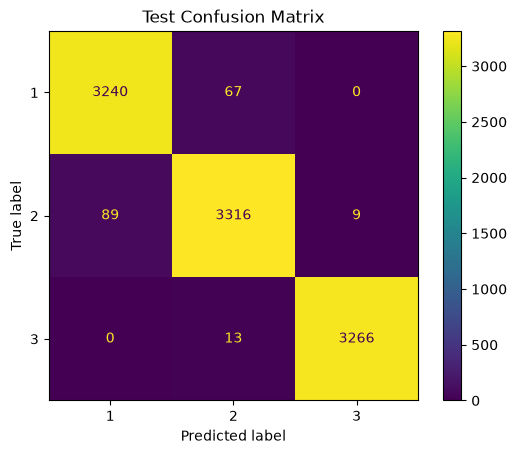

In [9]:
y_test_pred = model.predict(X_test1)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    values_format="d"
)

plt.title("Test Confusion Matrix")
plt.show()


## 8. Coefficients

In [10]:
# Binary: one coefficient per feature.
# Multinomial: one coefficient row per class.

if model.coef_.shape[0] == 1:
    coefficient_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    })
    display(coefficient_df)

else:
    coefficient_df = pd.DataFrame(
        model.coef_,
        index=[f"Class={c}" for c in model.classes_],
        columns=X_train1.columns
    )
    display(coefficient_df)


,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Stream_Civil,Stream_ECE,Stream_EE,Stream_IT,Stream_Mechanical,Specialisation_DataScience,Specialisation_Embedded,Specialisation_Networking,Hostel_Yes,HistoryOfBacklogs_Yes
Class=1,-0.042962,-3.080077,-2.757286,-2.933888,-2.928222,-2.980250,-3.202960,-3.129337,-3.317398,-2.307573,...,-0.042398,-0.161535,-0.318139,-0.164307,0.017923,0.026720,0.092280,0.091224,0.012351,-0.807099
Class=2,-0.004919,0.226022,0.140817,0.096865,0.075751,0.098003,0.340399,0.337369,0.312412,0.049333,...,0.018944,-0.063507,0.074061,-0.077319,-0.117652,-0.197300,-0.162788,-0.109682,0.058732,-0.258704
Class=3,0.047881,2.854056,2.616469,2.837023,2.852470,2.882247,2.862560,2.791968,3.004985,2.258240,...,0.023454,0.225042,0.244078,0.241626,0.099729,0.170581,0.070509,0.018458,-0.071083,1.065804


## 9. Coefficient Bar Chart

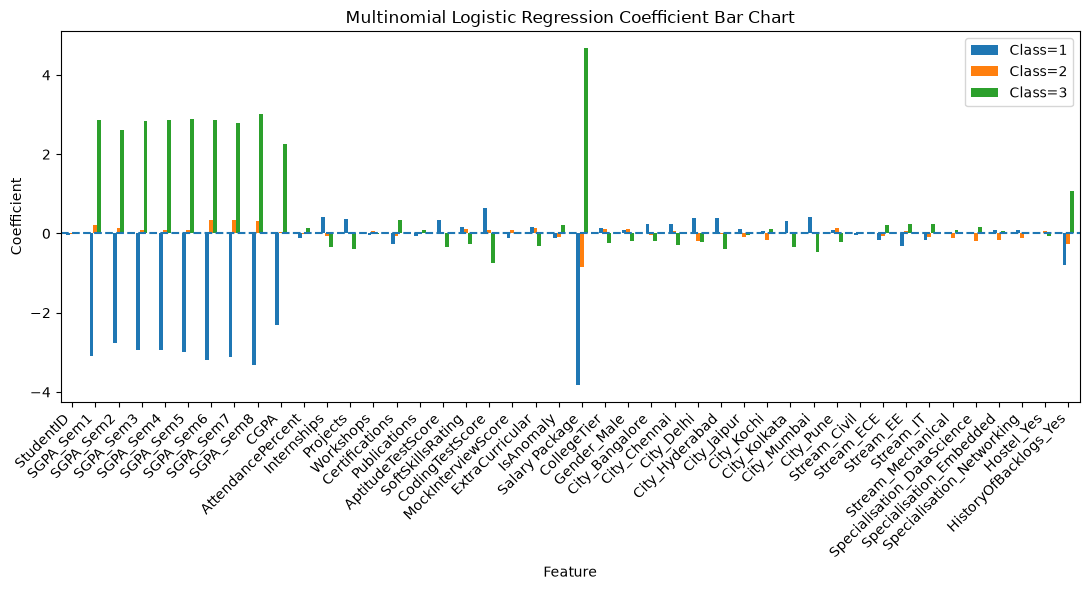

In [11]:
if model.coef_.shape[0] == 1:

    plot_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    }).sort_values("Coefficient")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["Feature"], plot_df["Coefficient"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title("Logistic Regression Coefficient Bar Chart")
    plt.tight_layout()
    plt.show()

else:
    coefficient_plot_df = coefficient_df.T

    ax = coefficient_plot_df.plot(
        kind="bar",
        figsize=(11, 6)
    )

    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Coefficient")
    ax.set_title("Multinomial Logistic Regression Coefficient Bar Chart")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Interpretation and Conclusion

### Target
This notebook predicts **`CGPA_Tier`**.

### Metrics
- Accuracy: overall percentage of correct predictions.
- Precision: correctness of positive predictions.
- Recall: ability to identify actual positive cases.
- F1-score: balance between precision and recall.
- ROC-AUC: used for the binary model to measure discrimination across thresholds.

### Coefficients
A positive coefficient increases the model's tendency toward the corresponding class; a negative coefficient decreases it, subject to the preprocessing and class formulation.

### Final evaluation
The **test-set metrics** are the final performance results because `X_test` and `y_test` are kept separate from model fitting.
